In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import FunctionTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as IMBPipeline
from pipeline_tree_model import get_preprocessor, feature_engineer
import joblib
from load_data import get_dataset
from print_metric import print_results

In [15]:
X_train, X_test, y_train, y_test = get_dataset()

In [16]:
pipe = IMBPipeline([
    ("feature_engineering", FunctionTransformer(feature_engineer, validate=False)),
    ("preprocessor", get_preprocessor()),
    ("smote", SMOTE(random_state=42)),
    ("model", XGBClassifier(random_state=42))
])

In [17]:
params_grid = {
    "model__objective": ["binary:logistic"],
    "model__n_estimators": [100, 200, 300, 400],
    "model__learning_rate": [0.01, 0.05, 0.5],
    "model__max_depth": [3, 4, 5, 6, 10],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.2, 0.5],
    "model__subsample": [0.7, 0.8],
    "model__colsample_bytree": [0.6, 0.8],
    "model__reg_alpha": [0, 0.1, 1],
    "model__reg_lambda": [0.1, 1, 5]
}

In [18]:
random_search = RandomizedSearchCV(pipe, param_distributions=params_grid, cv=5, verbose=1, n_jobs=-1, scoring="roc_auc", n_iter=200, random_state=42)

In [19]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.6, 0.8], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set

In [20]:
y_pred = random_search.predict(X_test)

In [21]:
y_pred_proba = random_search.predict_proba(X_test)

In [22]:
y_train_pred = random_search.predict(X_train)
y_train_pred_proba = random_search.predict_proba(X_train)

In [23]:
print("TRAINING RESULTS")
print_results(y_train, y_train_pred, y_train_pred_proba[:, 1])
print("\n")
print("TESTING RESULTS")
print_results(y_test, y_pred, y_pred_proba[:, 1])

TRAINING RESULTS
Accuracy Score 0.839541547277937
Recall Score 0.76
Precision Score 0.8085106382978723
ROC AUC Score 0.9121522411128283
F1 Score 0.7835051546391752
Confusion Matrix
[[575  72]
 [ 96 304]]
Classification Report
              precision    recall  f1-score   support

           0       0.86      0.89      0.87       647
           1       0.81      0.76      0.78       400

    accuracy                           0.84      1047
   macro avg       0.83      0.82      0.83      1047
weighted avg       0.84      0.84      0.84      1047



TESTING RESULTS
Accuracy Score 0.8320610687022901
Recall Score 0.78
Precision Score 0.78
ROC AUC Score 0.9065123456790124
F1 Score 0.78
Confusion Matrix
[[140  22]
 [ 22  78]]
Classification Report
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       162
           1       0.78      0.78      0.78       100

    accuracy                           0.83       262
   macro avg       0.82      

In [24]:
random_search.best_params_

{'model__subsample': 0.7,
 'model__reg_lambda': 1,
 'model__reg_alpha': 1,
 'model__objective': 'binary:logistic',
 'model__n_estimators': 100,
 'model__min_child_weight': 1,
 'model__max_depth': 5,
 'model__learning_rate': 0.05,
 'model__gamma': 0.2,
 'model__colsample_bytree': 0.6}

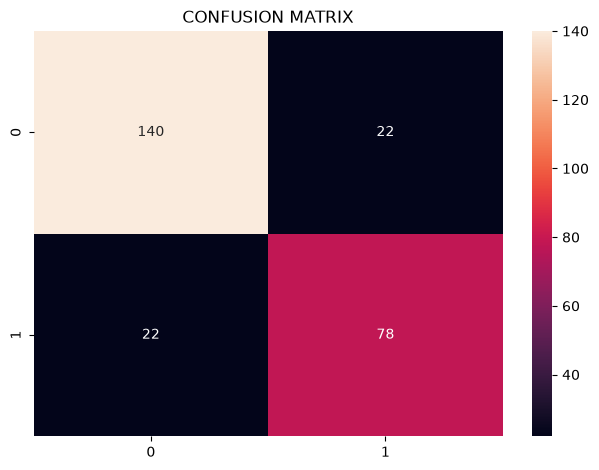

In [25]:
plt.title("CONFUSION MATRIX")
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.tight_layout()
plt.savefig("images/confusion_matrix_xgboost.png", dpi=1200)
plt.show()

In [26]:
joblib.dump(random_search, "models/xgboost.pkl")
print("Model Saved")

Model Saved
